Data Preview:


,timestamp,service,energy_type,usage_hours,cost_per_hour,total_cost
0,2024-01-01,Compute,Solar,5,2.0,10.0
1,2024-01-02,Storage,Wind,3,1.5,4.5
2,2024-01-03,Compute,Grid,6,2.5,15.0



Total Cost: 29.5

Cost by Energy:


energy_type
Grid     15.0
Solar    10.0
Wind      4.5
Name: total_cost, dtype: float64


Cost by Service:


service
Compute    25.0
Storage     4.5
Name: total_cost, dtype: float64


Plot: Cost by Energy Type


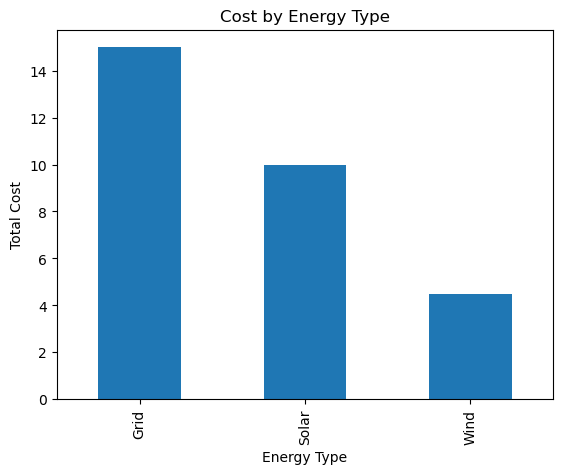


Plot: Daily Cost Trend


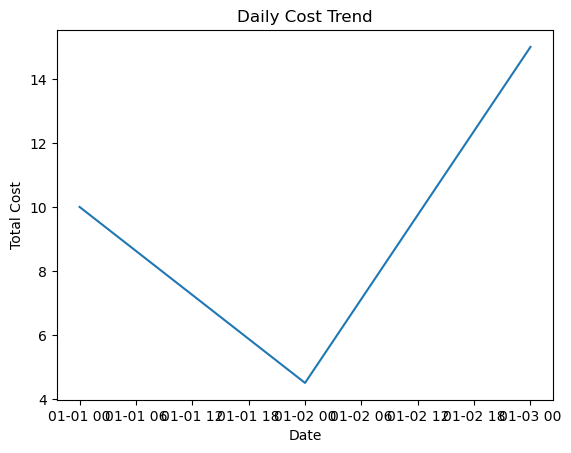


Anomalies:


,timestamp,service,energy_type,usage_hours,cost_per_hour,total_cost



Idle Resources:


,timestamp,service,energy_type,usage_hours,cost_per_hour,total_cost


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

file_path =r"C:\Users\More\OneDrive\Documents\GitHub\cloud-cost-intelligence-energy\data\sample_data.xlsx"

df = pd.read_excel(file_path)

df.columns = df.columns.str.strip().str.lower()

df['timestamp'] = pd.to_datetime(df['timestamp'])

df['total_cost'] = df['usage_hours'] * df['cost_per_hour']

print("Data Preview:")
display(df.head())

print("\nTotal Cost:", df['total_cost'].sum())

cost_by_energy = df.groupby('energy_type')['total_cost'].sum()
print("\nCost by Energy:")
display(cost_by_energy)

cost_by_service = df.groupby('service')['total_cost'].sum()
print("\nCost by Service:")
display(cost_by_service)

print("\nPlot: Cost by Energy Type")
cost_by_energy.plot(kind='bar')
plt.title("Cost by Energy Type")
plt.xlabel("Energy Type")
plt.ylabel("Total Cost")
plt.show()

print("\nPlot: Daily Cost Trend")
daily_cost = df.groupby(df['timestamp'].dt.date)['total_cost'].sum()
daily_cost.plot()
plt.title("Daily Cost Trend")
plt.xlabel("Date")
plt.ylabel("Total Cost")
plt.show()

threshold = df['total_cost'].mean() * 2
anomalies = df[df['total_cost'] > threshold]
print("\nAnomalies:")
display(anomalies)

idle = df[df['usage_hours'] < 1]
print("\nIdle Resources:")
display(idle)